In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ─── Load ───────────────────────────────────────────────
df = pd.read_csv("cardekho_dataset.csv")
df_copy = df.copy()

print("Shape    :", df.shape)
print("Columns  :", df.columns.tolist())
print()
print(df.dtypes)
print()
df.head()

Shape    : (15411, 14)
Columns  : ['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

Unnamed: 0             int64
car_name              object
brand                 object
model                 object
vehicle_age            int64
km_driven              int64
seller_type           object
fuel_type             object
transmission_type     object
mileage              float64
engine                 int64
max_power            float64
seats                  int64
selling_price          int64
dtype: object



,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


___
# Nan Values
___

In [3]:
# ─── Missing Values ──────────────────────────────────────
print("Missing values:")
print(df.isnull().sum())
print()
print(f"Total missing: {df.isnull().sum().sum()}")

Missing values:
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

Total missing: 0


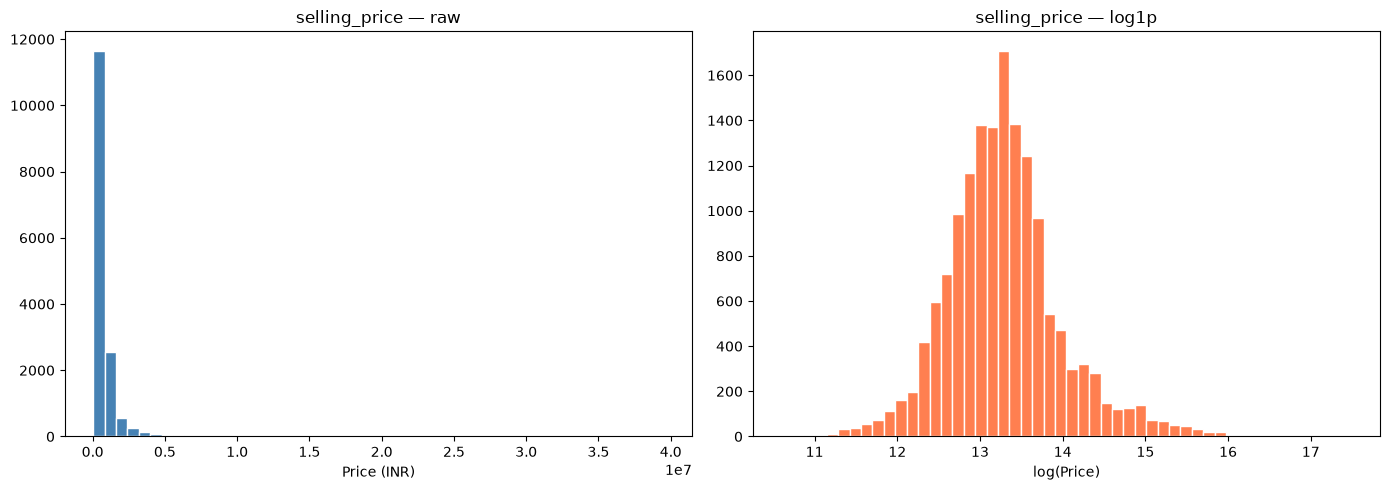

count    1.541100e+04
mean     7.749711e+05
std      8.941284e+05
min      4.000000e+04
25%      3.850000e+05
50%      5.560000e+05
75%      8.250000e+05
max      3.950000e+07
Name: selling_price, dtype: float64


In [4]:
# ─── Target Distribution ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw
axes[0].hist(df['selling_price'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('selling_price — raw')
axes[0].set_xlabel('Price (INR)')

# Log transformed
axes[1].hist(np.log1p(df['selling_price']), bins=50, color='coral', edgecolor='white')
axes[1].set_title('selling_price — log1p')
axes[1].set_xlabel('log(Price)')

plt.tight_layout()
plt.show()

print(df['selling_price'].describe())

max_power      0.758597
engine         0.653873
seats          0.230034
km_driven     -0.095265
mileage       -0.301869
vehicle_age   -0.485280
Name: log_price, dtype: float64


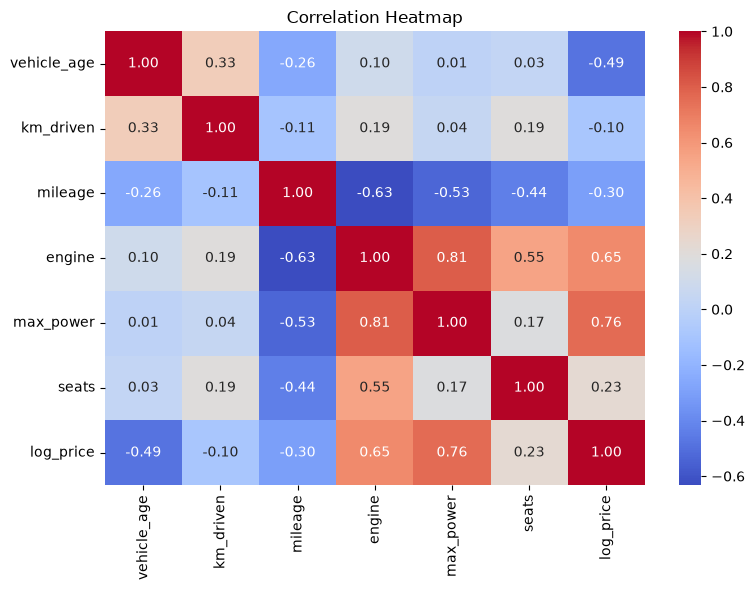

In [5]:
# ─── Correlation with Target ─────────────────────────────
df['log_price'] = np.log1p(df['selling_price'])

numerical_cols = ['vehicle_age', 'km_driven', 'mileage', 
                  'engine', 'max_power', 'seats']

corr = df[numerical_cols + ['log_price']].corr()['log_price'].drop('log_price')
print(corr.sort_values(ascending=False))

# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    df[numerical_cols + ['log_price']].corr(),
    annot=True, fmt='.2f', cmap='coolwarm'
)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

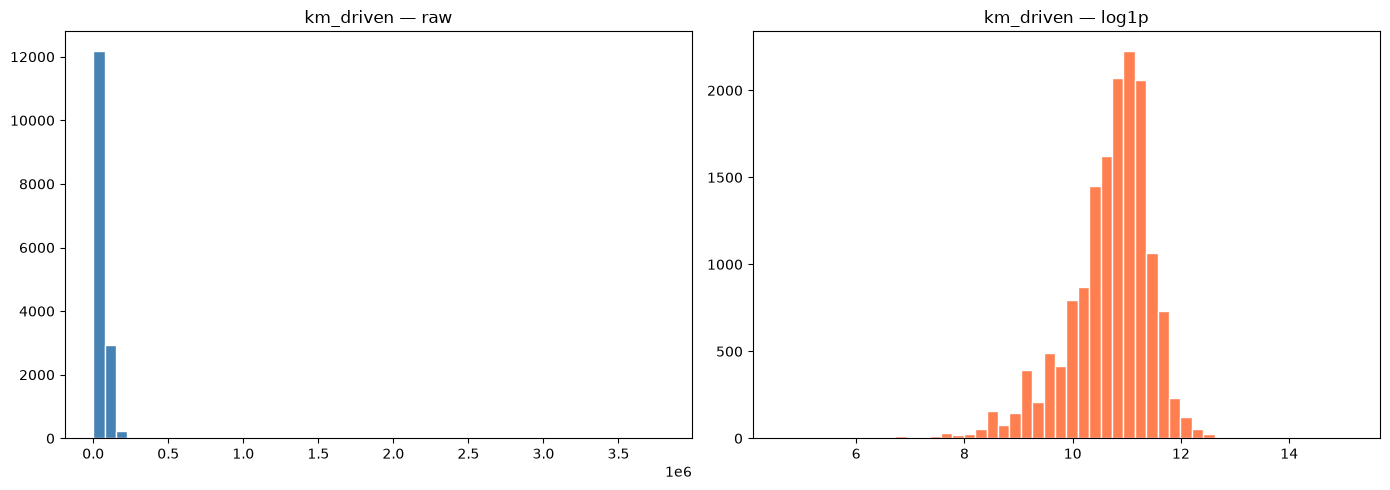

count    1.541100e+04
mean     5.561648e+04
std      5.161855e+04
min      1.000000e+02
25%      3.000000e+04
50%      5.000000e+04
75%      7.000000e+04
max      3.800000e+06
Name: km_driven, dtype: float64


In [6]:
# ─── km_driven skew check ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['km_driven'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('km_driven — raw')

axes[1].hist(np.log1p(df['km_driven']), bins=50, color='coral', edgecolor='white')
axes[1].set_title('km_driven — log1p')

plt.tight_layout()
plt.show()

print(df['km_driven'].describe())

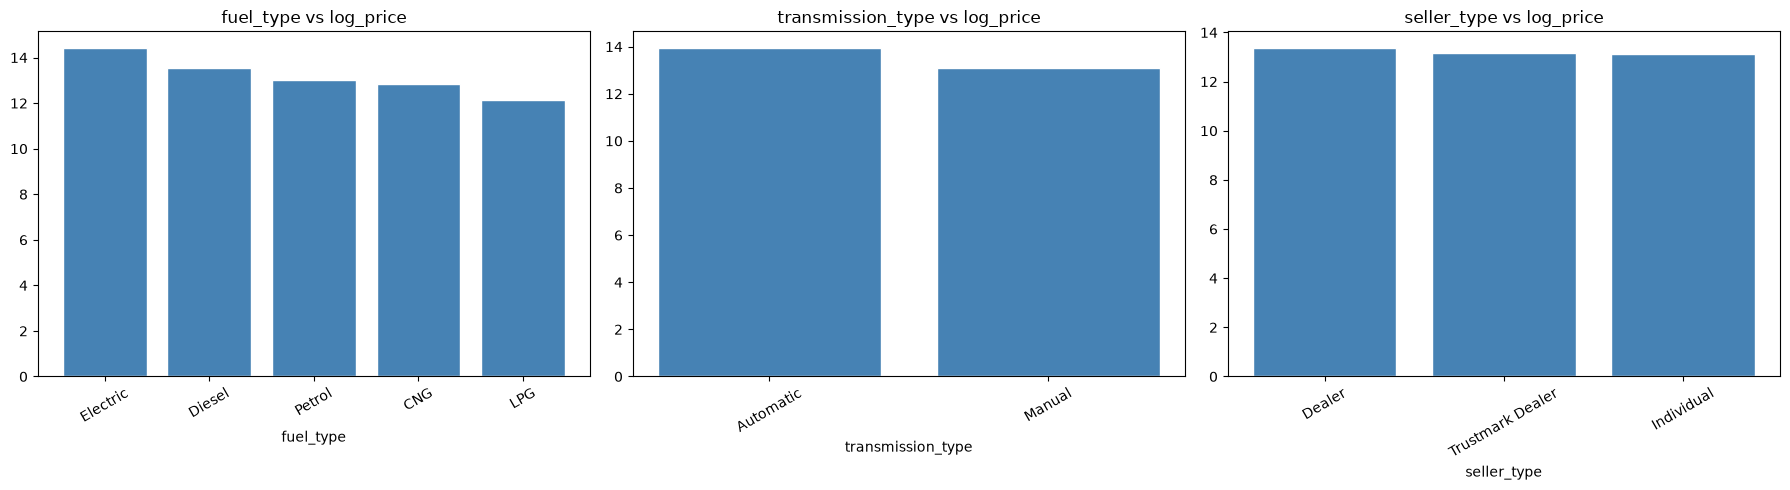


fuel_type:
fuel_type
Petrol      7643
Diesel      7419
CNG          301
LPG           44
Electric       4
Name: count, dtype: int64

transmission_type:
transmission_type
Manual       12225
Automatic     3186
Name: count, dtype: int64

seller_type:
seller_type
Dealer              9539
Individual          5699
Trustmark Dealer     173
Name: count, dtype: int64

seats:
seats
5    12910
7     1922
8      311
6      127
4       77
9       55
2        7
0        2
Name: count, dtype: int64


In [7]:
# ─── Categorical vs Price ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ['fuel_type', 'transmission_type', 'seller_type']):
    means = df.groupby(col)['log_price'].mean().sort_values(ascending=False)
    ax.bar(means.index, means.values, color='steelblue', edgecolor='white')
    ax.set_title(f'{col} vs log_price')
    ax.set_xlabel(col)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# Value counts
for col in ['fuel_type', 'transmission_type', 'seller_type', 'seats']:
    print(f"\n{col}:")
    print(df[col].value_counts())

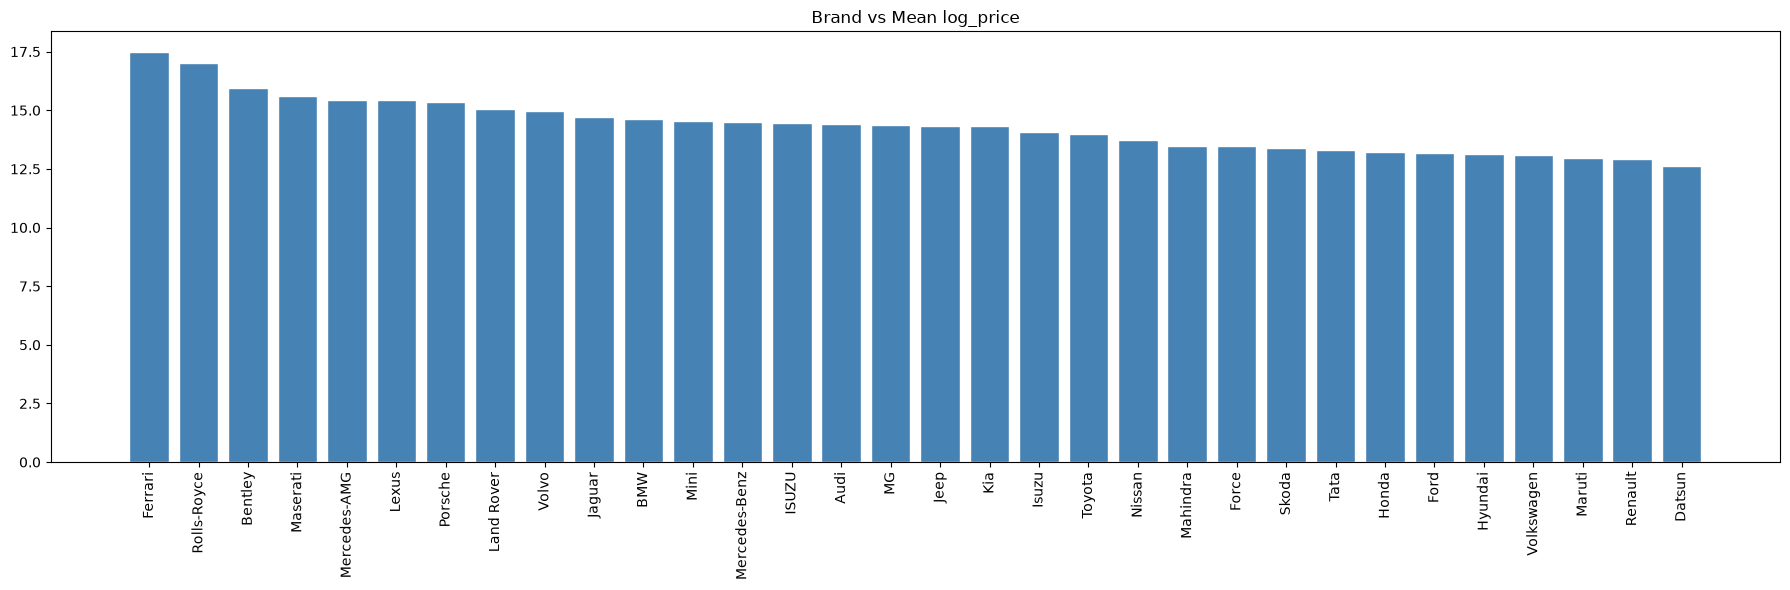

Total brands: 32
Total models: 120

Bottom 10 brands by count:
brand
Nissan          11
Lexus           10
Isuzu            8
Bentley          3
Maserati         2
ISUZU            2
Ferrari          1
Mercedes-AMG     1
Rolls-Royce      1
Force            1
Name: count, dtype: int64


In [8]:
# ─── Brand vs Price ──────────────────────────────────────
plt.figure(figsize=(18, 6))

brand_means = df.groupby('brand')['log_price'].mean().sort_values(ascending=False)
plt.bar(brand_means.index, brand_means.values, color='steelblue', edgecolor='white')
plt.xticks(rotation=90)
plt.title('Brand vs Mean log_price')
plt.tight_layout()
plt.show()

print("Total brands:", df['brand'].nunique())
print("Total models:", df['model'].nunique())
print("\nBottom 10 brands by count:")
print(df['brand'].value_counts().tail(10))

/tmp/ipykernel_3369/3987166656.py:8: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[col].dropna(), vert=True)
/tmp/ipykernel_3369/3987166656.py:8: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[col].dropna(), vert=True)
/tmp/ipykernel_3369/3987166656.py:8: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[col].dropna(), vert=True)
/tmp/ipykernel_3369/3987166656.py:8: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[col].dropna(), vert=True)
/tmp/ipykernel_3369/3987166656.py:8: MatplotlibDeprecati

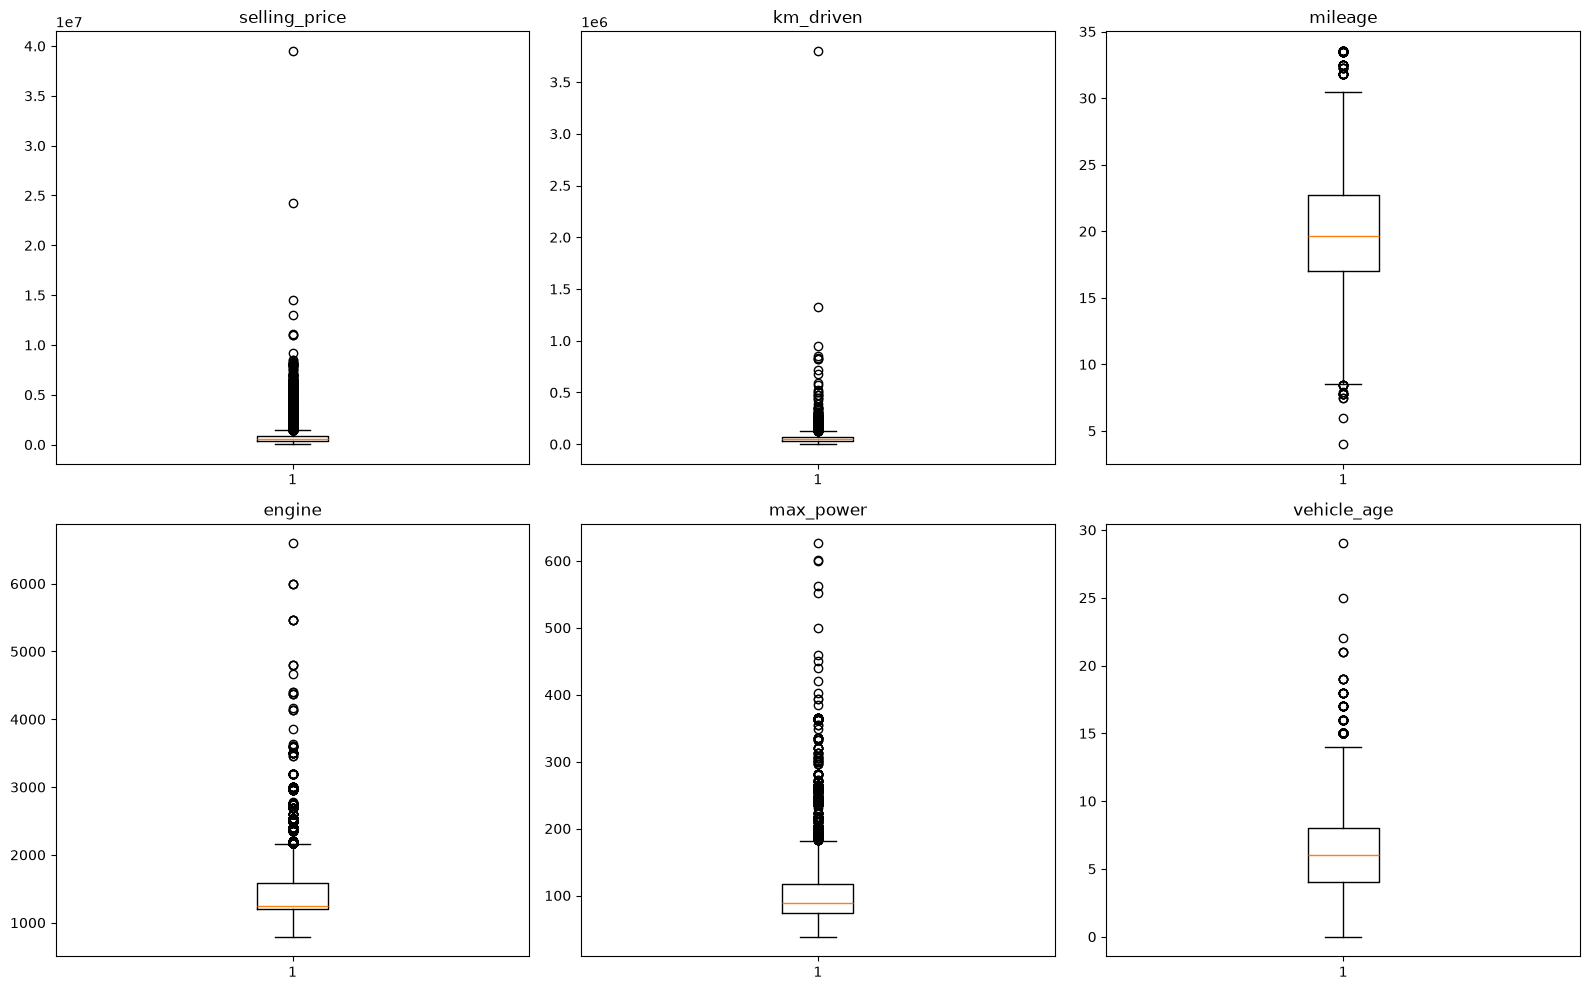

Outlier counts (IQR method):
  selling_price       : 1386 outliers (9.0%)
  km_driven           : 466 outliers (3.0%)
  mileage             : 88 outliers (0.6%)
  engine              : 2130 outliers (13.8%)
  max_power           : 867 outliers (5.6%)
  vehicle_age         : 154 outliers (1.0%)


In [9]:
# ─── Outlier Check ───────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

cols = ['selling_price', 'km_driven', 'mileage', 
        'engine', 'max_power', 'vehicle_age']

for ax, col in zip(axes.flatten(), cols):
    ax.boxplot(df[col].dropna(), vert=True)
    ax.set_title(col)

plt.tight_layout()
plt.show()

# IQR outlier count per column
print("Outlier counts (IQR method):")
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"  {col:20s}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)")

In [10]:
# ─── Apply all cleaning decisions ────────────────────────

df_clean = df.copy()

# 1. Drop irrelevant cols
df_clean = df_clean.drop(['Unnamed: 0', 'car_name'], axis=1)

# 2. Drop rare fuel types
df_clean = df_clean[~df_clean['fuel_type'].isin(['Electric', 'LPG'])]

# 3. Merge Trustmark Dealer
df_clean['seller_type'] = df_clean['seller_type'].replace(
    'Trustmark Dealer', 'Dealer'
)

# 4. Drop bad seats
df_clean = df_clean[df_clean['seats'] > 0]
df_clean = df_clean[df_clean['seats'] != 2]

# 5. Cap km_driven
Q3  = df_clean['km_driven'].quantile(0.75)
IQR = Q3 - df_clean['km_driven'].quantile(0.25)
df_clean['km_driven'] = df_clean['km_driven'].clip(upper=Q3 + 1.5*IQR)

# 6. Log1p transform skewed columns
df_clean['km_driven']     = np.log1p(df_clean['km_driven'])
df_clean['selling_price'] = np.log1p(df_clean['selling_price'])

# ─── Final shape ─────────────────────────────────────────
print("Final clean shape:", df_clean.shape)
print("\nDtypes:")
print(df_clean.dtypes)
print("\nSample:")
df_clean.head()

Final clean shape: (15354, 13)

Dtypes:
brand                 object
model                 object
vehicle_age            int64
km_driven            float64
seller_type           object
fuel_type             object
transmission_type     object
mileage              float64
engine                 int64
max_power            float64
seats                  int64
selling_price        float64
log_price            float64
dtype: object

Sample:


,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price,log_price
0,Maruti,Alto,9,11.695255,Individual,Petrol,Manual,19.70,796,46.30,5,11.695255,11.695255
1,Hyundai,Grand,5,9.903538,Individual,Petrol,Manual,18.90,1197,82.00,5,13.217675,13.217675
2,Hyundai,i20,11,11.002117,Individual,Petrol,Manual,17.00,1197,80.00,5,12.278398,12.278398
3,Maruti,Alto,9,10.518700,Individual,Petrol,Manual,20.92,998,67.10,5,12.328295,12.328295
4,Ford,Ecosport,6,10.308986,Dealer,Diesel,Manual,22.77,1498,98.59,5,13.253393,13.253393


In [11]:
# ─── BUG FIX: drop duplicate log_price col ───────────────
df_clean = df_clean.drop('log_price', axis=1)

print("Final cols:", df_clean.columns.tolist())
print("Final shape:", df_clean.shape)

Final cols: ['brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']
Final shape: (15354, 12)


In [12]:
# ─── EDA Complete Summary ────────────────────────────────
print("=" * 50)
print("EDA COMPLETE — DATASET READY")
print("=" * 50)
print(f"Rows              : {df_clean.shape[0]}")
print(f"Features          : {df_clean.shape[1] - 1}")
print(f"Target            : selling_price (log1p transformed)")
print()
print("Numerical features:")
num_cols = ['vehicle_age','km_driven','mileage','engine','max_power','seats']
print(" ", num_cols)
print()
print("Categorical features:")
cat_cols = ['brand','seller_type','fuel_type','transmission_type']
print(" ", cat_cols)
print()
print("Transformations applied:")
print("  km_driven     → capped + log1p")
print("  selling_price → log1p (remember expm1 at prediction)")
print()
print("Next step: ANN project with pipeline architecture")



EDA COMPLETE — DATASET READY
Rows              : 15354
Features          : 11
Target            : selling_price (log1p transformed)

Numerical features:
  ['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']

Categorical features:
  ['brand', 'seller_type', 'fuel_type', 'transmission_type']

Transformations applied:
  km_driven     → capped + log1p
  selling_price → log1p (remember expm1 at prediction)

Next step: ANN project with pipeline architecture


```
Rows            : 15,354
Input features  : 10 (6 numerical + 4 categorical)
Target          : log1p(selling_price) → expm1() at prediction time

Dropped         : Unnamed:0, car_name, model, Electric, LPG rows
Merged          : Trustmark Dealer → Dealer
Dropped         : seats=0, seats=2
Capped          : km_driven at Q3+1.5×IQR
Log transformed : km_driven, selling_price

Expected R²     : >0.90 (strong correlations confirmed)

___
# Model Trainig
___

In [13]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import dill, datetime, os

# ─── Use df_clean from EDA cells directly ────────────────
# IMP: drop log_price if still exists
if 'log_price' in df_clean.columns:
    df_clean = df_clean.drop('log_price', axis=1)

print("Shape:", df_clean.shape)
print("Cols :", df_clean.columns.tolist())

I0000 00:00:1788517821.061363    3369 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788517822.409146    3369 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788517825.802819    3369 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Shape: (15354, 12)
Cols : ['brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']


In [14]:
# ─── X y Split ───────────────────────────────────────────
X = df_clean.drop('selling_price', axis=1)
y = df_clean['selling_price']   # already log1p transformed

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\ny sample (log scale):")
print(y.describe())

X shape: (15354, 11)
y shape: (15354,)

y sample (log scale):
count    15354.000000
mean        13.281697
std          0.683447
min         10.596660
25%         12.861001
50%         13.235694
75%         13.623140
max         17.491811
Name: selling_price, dtype: float64


In [15]:
# ─── Feature columns ─────────────────────────────────────
numerical_cols    = ['vehicle_age', 'km_driven', 'mileage',
                     'engine', 'max_power', 'seats']

categorical_cols  = ['brand', 'model', 'seller_type', 
                     'fuel_type', 'transmission_type']

# ─── ColumnTransformer ───────────────────────────────────
# IMP: OHE categoricals + StandardScale numericals in one pipeline
preprocessor = ColumnTransformer( transformers=[
    ("num", StandardScaler(), numerical_cols),
    ("cat", OneHotEncoder(sparse_output=False, handle_unknown="ignore"), categorical_cols)
])

print("Preprocessor ready")
print(f"Numerical  : {numerical_cols}")
print(f"Categorical: {categorical_cols}")

Preprocessor ready
Numerical  : ['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']
Categorical: ['brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']


In [16]:
# ─── Train Test Split ────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# ─── Fit on train only, transform both ───────────────────
# IMP: never fit on test data — data leakage
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

print("X_train_processed shape:", X_train_processed.shape)
print("X_test_processed shape :", X_test_processed.shape)
print(f"\nTotal input features to ANN: {X_train_processed.shape[1]}")

X_train_processed shape: (12283, 159)
X_test_processed shape : (3071, 159)

Total input features to ANN: 159


In [17]:
print(X_train.columns.tolist())
print(categorical_cols)

['brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats']
['brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']


___
# ANN Model 
___

In [18]:
# ─── ANN Architecture ────────────────────────────────────
# 44 inputs → 256 → 128 → 64 → 1 (linear output)

n_features = X_train_processed.shape[1]

model = Sequential([
    # HL1
    Dense(256, activation='relu', input_shape=(n_features,)),
    BatchNormalization(),
    Dropout(0.1),

    # HL2
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.1),

    # HL3
    Dense(64, activation='relu'),
    Dropout(0.1),

    # Output — linear, no activation for regression
    Dense(1)
])

model.summary()

/home/aizen/miniconda3/envs/gensim-env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1788517827.168266    3369 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        40,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83,713 (327.00 KB)

 Trainable params: 82,945 (324.00 KB)

 Non-trainable params: 768 (3.00 KB)

In [19]:
# ─── Compile ─────────────────────────────────────────────
opt = Adam(learning_rate=0.001)

model.compile(
    optimizer=opt,
    loss='mae',
    metrics=['mae']
)

print("Model compiled")

Model compiled


In [20]:
# ─── Callbacks ───────────────────────────────────────────
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),
    TensorBoard(log_dir=log_dir, histogram_freq=1)
]

# ─── Train ───────────────────────────────────────────────
history = model.fit(
    X_train_processed,
    y_train,
    validation_data=(X_test_processed, y_test),  # IMP: test not train
    epochs=100,
    batch_size=32,
    callbacks=callbacks
)

Epoch 1/100
384/384 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 2.3570 - mae: 2.3570 - val_loss: 0.5842 - val_mae: 0.5842
Epoch 2/100
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.1962 - mae: 1.1962 - val_loss: 0.3425 - val_mae: 0.3425
Epoch 3/100
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.0562 - mae: 1.0562 - val_loss: 0.4317 - val_mae: 0.4317
Epoch 4/100
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.9877 - mae: 0.9877 - val_loss: 0.4004 - val_mae: 0.4004
Epoch 5/100
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.9267 - mae: 0.9267 - val_loss: 0.4148 - val_mae: 0.4148
Epoch 6/100
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.8794 - mae: 0.8794 - val_loss: 0.2672 - val_mae: 0.2672
Epoch 7/100
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.8506 - mae: 0.8506 - val_loss: 0.3189 - val_mae: 0.3189
Epoch 8/100
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.8232 - mae: 0.8232 - val_loss: 0.3056 - val_mae: 0.3056
Epoch 9/100
384/384 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/

In [21]:
# ─── Evaluation ──────────────────────────────────────────
test_loss, test_mae = model.evaluate(X_test_processed, y_test)

# Predictions in log scale
y_pred_log = model.predict(X_test_processed).flatten()

# Convert back to actual rupees
# IMP: expm1 reverses log1p
y_pred_actual = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test)

# ─── Metrics in real rupees ──────────────────────────────
mae  = mean_absolute_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
r2   = r2_score(y_test, y_pred_log)   # R² on log scale

print("=" * 45)
print("MODEL EVALUATION")
print("=" * 45)
print(f"Log scale MAE  : {test_mae:.4f}")
print(f"Real MAE       : ₹{mae:,.0f}")
print(f"Real RMSE      : ₹{rmse:,.0f}")
print(f"R² (log scale) : {r2:.4f}")
print()
print(f"Mean actual price : ₹{y_test_actual.mean():,.0f}")
print(f"Avg prediction off: ₹{mae:,.0f}")
print(f"That is {mae/y_test_actual.mean()*100:.1f}% error on average")

96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1376 - mae: 0.1376
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MODEL EVALUATION
Log scale MAE  : 0.1376
Real MAE       : ₹119,918
Real RMSE      : ₹392,589
R² (log scale) : 0.9319

Mean actual price : ₹786,785
Avg prediction off: ₹119,918
That is 15.2% error on average


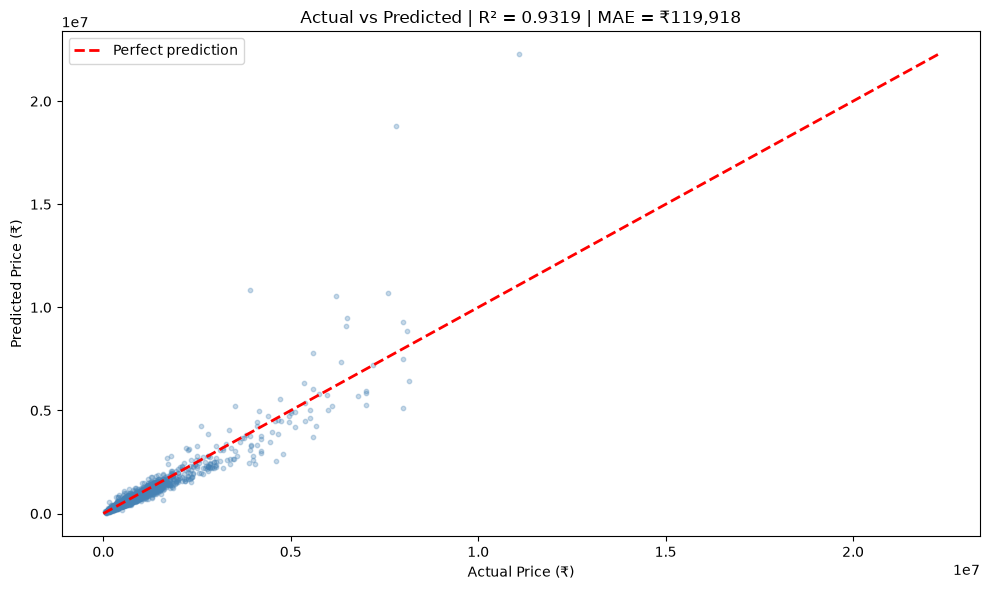

In [22]:
# ─── Actual vs Predicted ─────────────────────────────────
plt.figure(figsize=(10, 6))

plt.scatter(y_test_actual, y_pred_actual, alpha=0.3, color='steelblue', s=10)

# Perfect prediction line
max_val = max(y_test_actual.max(), y_pred_actual.max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect prediction')

plt.xlabel('Actual Price (₹)')
plt.ylabel('Predicted Price (₹)')
plt.title(f'Actual vs Predicted | R² = {r2:.4f} | MAE = ₹{mae:,.0f}')
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
print("Unique brands :", df_clean['brand'].nunique())
print("Unique models :", df_clean['model'].nunique())

Unique brands : 32
Unique models : 119
